2026-09-29 15:12:19.834919: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-29 15:12:19.836630: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-29 15:12:19.865302: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-29 15:12:19.865934: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-29 15:12:20.453233: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

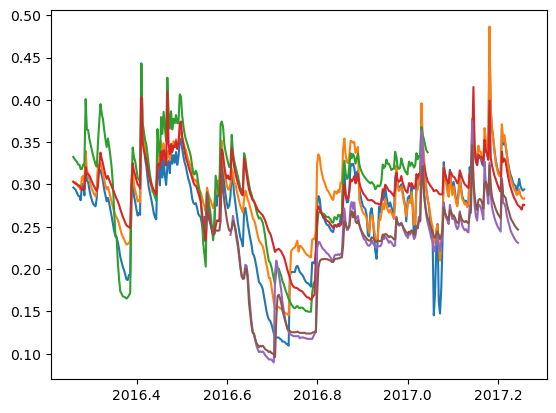

6


In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import os
import sys
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)
from pathlib import Path
home = Path.home()
subdir = home / "src" / "at-gpflow" / "experiments" / "soil-moisture" / "Wageningen" ## or whatever folder at-gpflow lives in
at_dir = home / "src" / "at-gpflow"


sys.path.append(str(at_dir))
sys.path.append(str(subdir))
BASE = str(subdir)

# Experiment 1: different substations using multiple depths
station_indices = ["04", "04", "01", "01", "05", "05"]
depths = [5, 10, 5, 10, 5, 10]
substations = []

# Experiment 2: different substations at the same depth
# station_indices = [f"0{d}" for d in range(1, 6)]
# depths = [10 for d in range(1, 6)]
# substations = []

# # Experiment 3: same substation, different depths
# station_indices = [f"15" for d in range(1, 6)]
# depths = [5, 10, 20, 40, 80]

substations = []
for station, depth in zip(station_indices, depths):

    source = pd.read_csv(BASE+f"/data/station_data/RM_SM_{station}_calibrated.csv")
    source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
    source.index = source["Measurement Time"]
    source = source.resample("6H").last()

    source['decimal_year'] = source['Measurement Time'].dt.year + (source['Measurement Time'].dt.dayofyear - 1) / 365.25
    source.index = source["decimal_year"]
    substations.append(source)

    plt.plot(source.index, source[f"{depth} cm VWC [m3/m3]"])
plt.show()

print(len(substations))


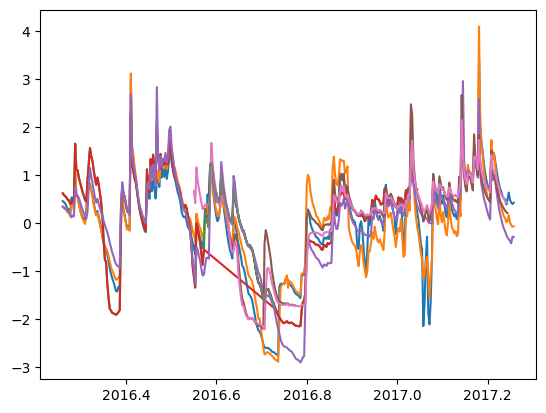

1818


In [ ]:
condition_index = 2
data_X = []
data_Y = []

for i, (depth, data) in enumerate(zip(depths, substations)):
    Ay = data[f"{depth} cm VWC [m3/m3]"].to_numpy().reshape(-1, 1) 
    Ax = data.index.to_numpy().reshape(-1, 1)
    Ax = Ax[~np.isnan(Ay)].reshape(-1, 1)
    Ay = Ay[~np.isnan(Ay)].reshape(-1, 1)
    Ay = (Ay - Ay.mean()) / np.std(Ay)

    plt.plot(Ax, Ay)
    if i == condition_index:
        n_test = int(0.2*len(Ax))
        start = int(2*int(len(Ax))/5)
        end = start + n_test
        Xtest, ytest = Ax[start:end], Ay[start:end]
        Ax, Ay = np.concatenate((Ax[:start], Ax[end:])), np.concatenate((Ay[:start], Ay[end:]))
        plt.plot(Ax, Ay)
        plt.plot(Xtest, ytest, color="k")
    data_X.append(np.hstack((Ax, i*np.ones_like(Ax))))
    data_Y.append(np.hstack((Ay, i*np.ones_like(Ay))))

X = np.vstack(tuple(data_X))
y = np.vstack(tuple(data_Y))
plt.plot(Xtest, ytest)
plt.show()
print(len(X))

/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────

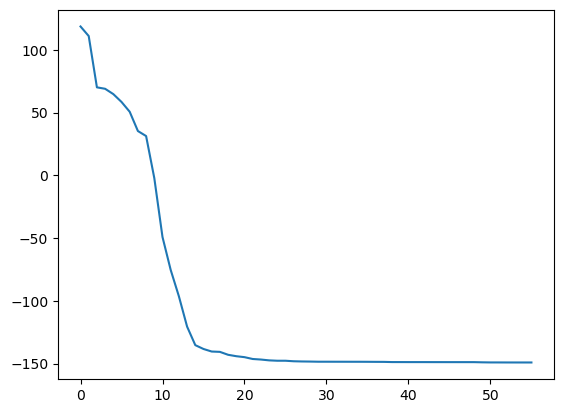

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                               │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.12448                             │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.013905920261892102          

In [3]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

model1 = ConditionalMOGP((X, y), kernel=kern, conditioning_index=condition_index, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

gpf.utilities.print_summary(model1)
optimize(model1)
gpf.utilities.print_summary(model1)


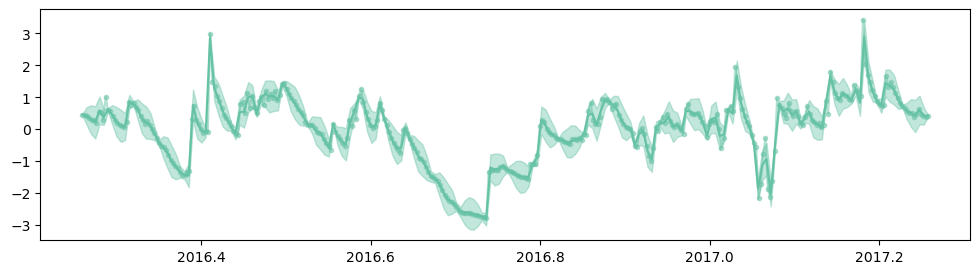

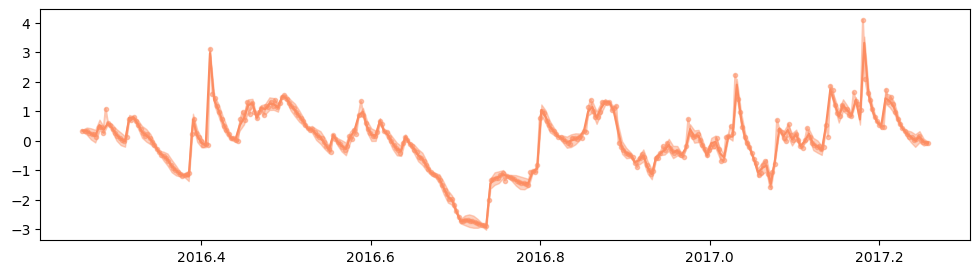

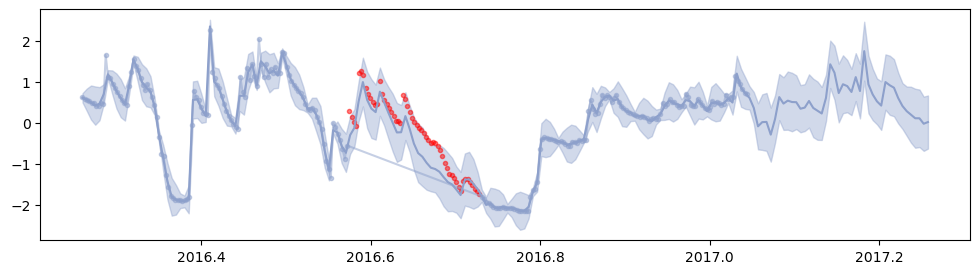

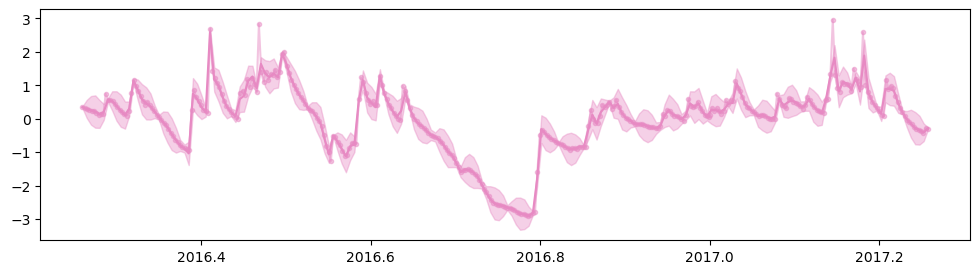

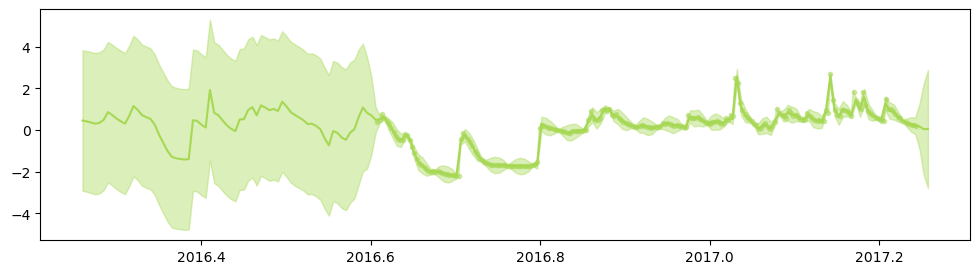

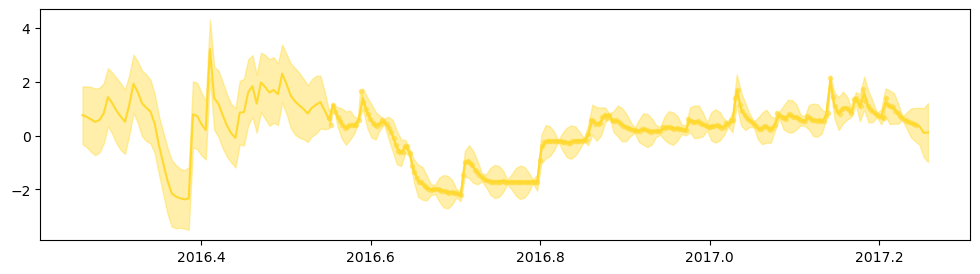

0.13926685988572055

In [4]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model1.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model1.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤

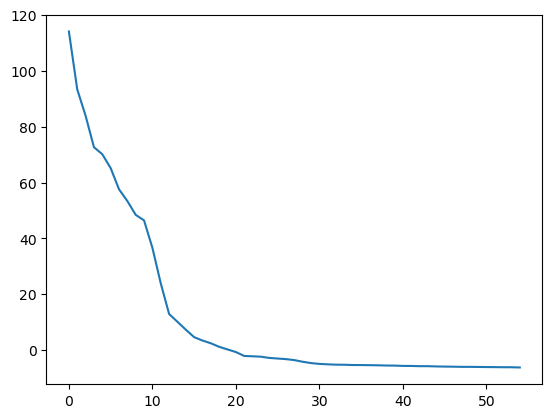

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.8672095477515751                                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │

In [5]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind) 
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
model2 = SparseCMOGP((X, y), conditioning_index=condition_index, exact_target=False, kernel=kern, jitter=1e-5, inducing_variable=LMCInducingPointsBase(ivs), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))


gpf.utilities.print_summary(model2)
optimize(model2)
gpf.utilities.print_summary(model2)

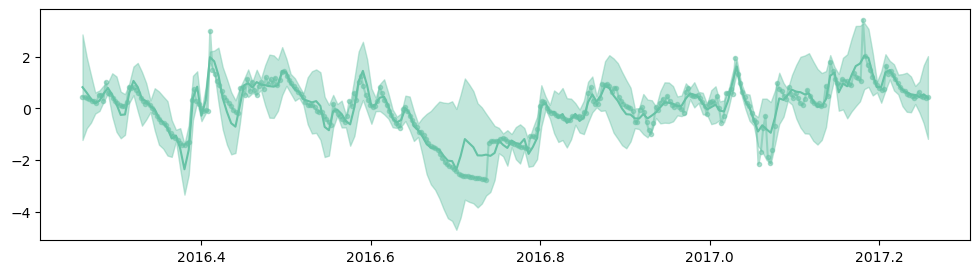

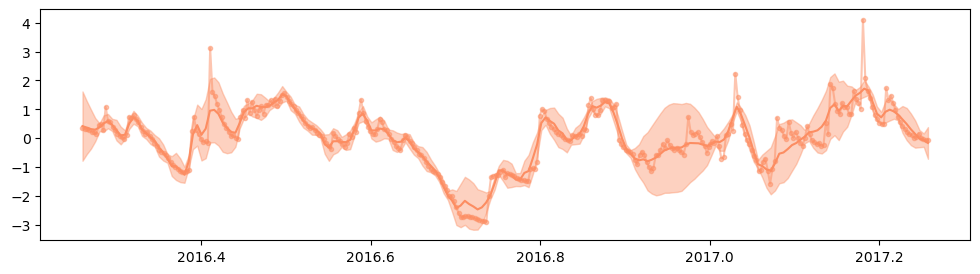

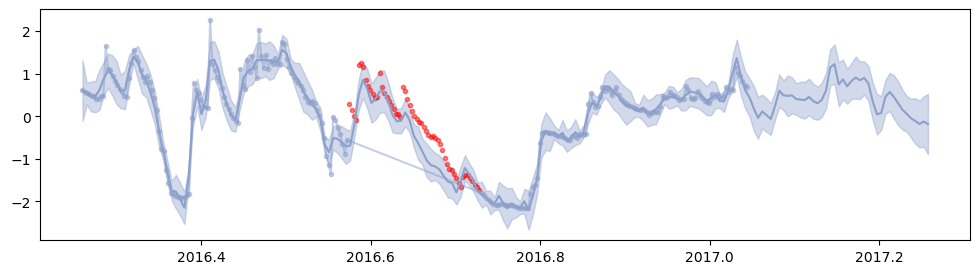

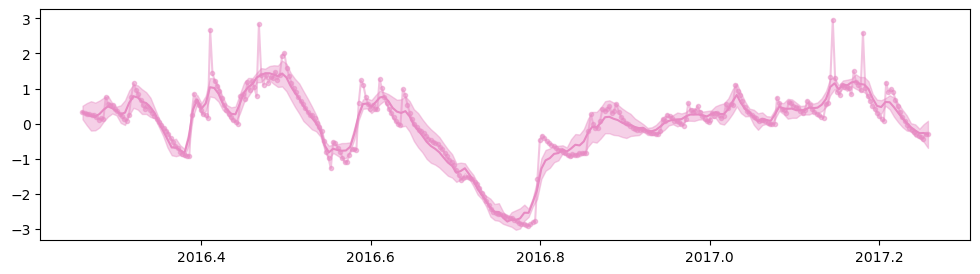

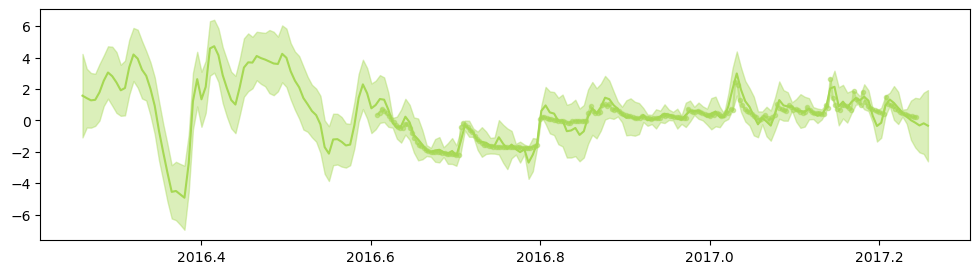

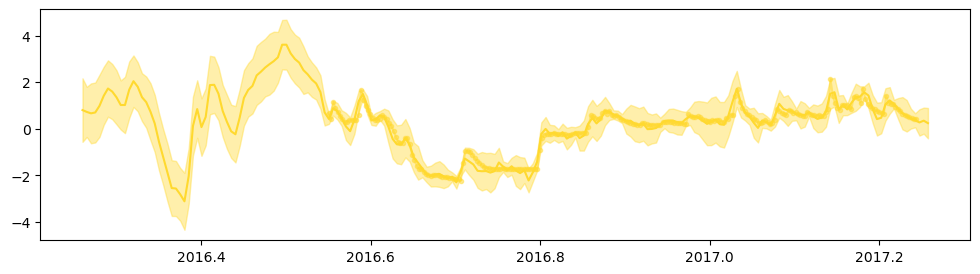

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.8672095477515751                                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │

0.17397412901279916

In [6]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)
colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model2.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model2.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()
gpf.utilities.print_summary(model2)

ours_mse = mean_squared_error(ytest, fmean_test)
ours_mse

In [7]:
print(len(X))

1818


In [8]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
kern = k * coreg
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

l1 = gpf.likelihoods.Gaussian()
l2 = gpf.likelihoods.Gaussian()
lik = gpf.likelihoods.SwitchedLikelihood(
    [l1 if i != condition_index else l2 for i in range(output_dim)]
)
# now build the GP model as normal
model3 =  gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=LMCInducingPointsBase(ivs))


gpf.utilities.print_summary(model3)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model3.training_loss_closure((X, y)),
    model3.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(model3)

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼────────────

2026-09-29 15:14:19.955226: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-29 15:14:20.061979: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════════════════════════════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape         │ dtype   │ value                                                │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════════════════════════════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()            │ float64 │ 0.4349275996024545                                   │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────────────────────────────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ (

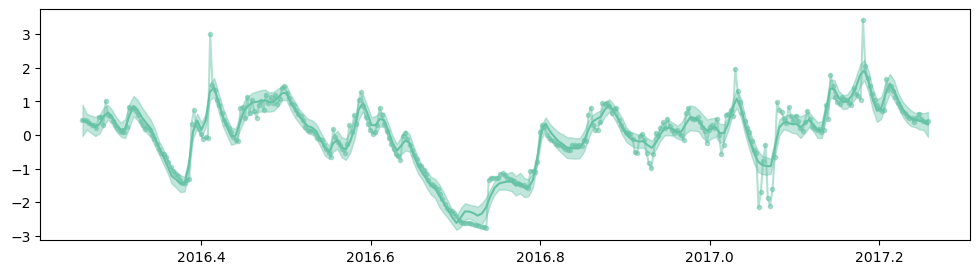

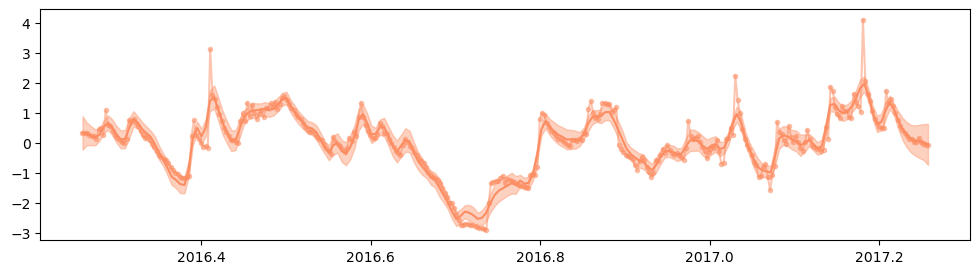

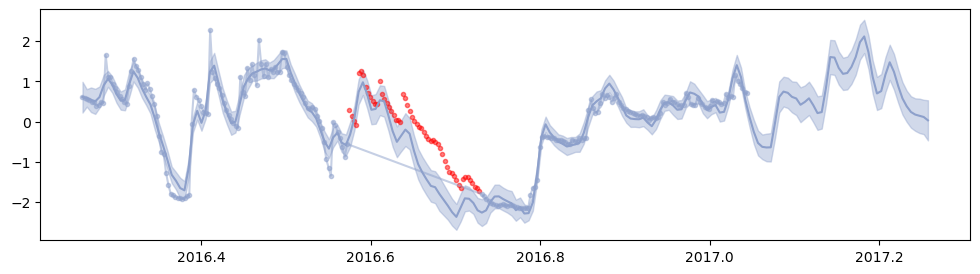

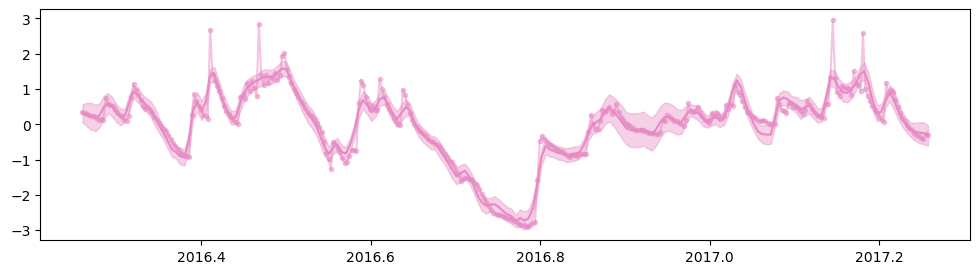

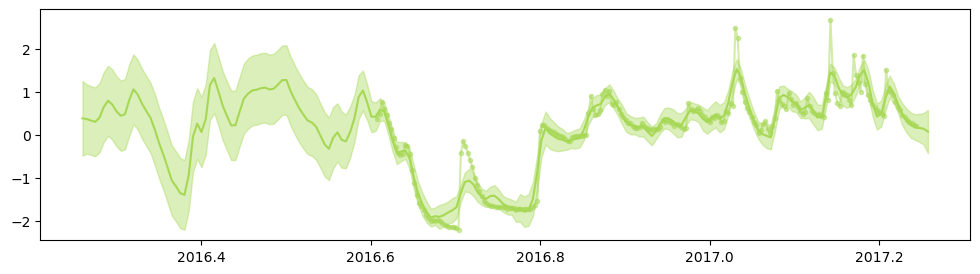

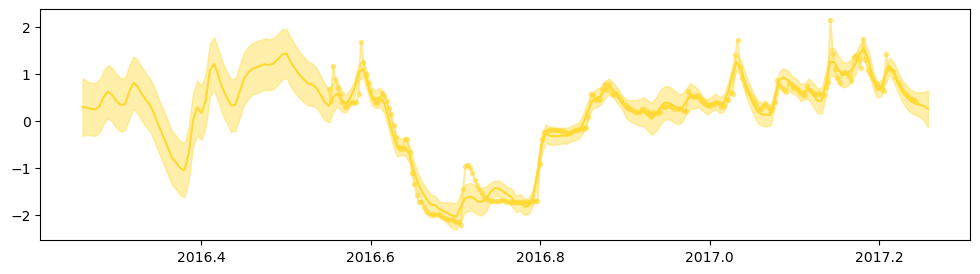

tf.Tensor(
[[-0.36080577]
 [-0.20358938]
 [ 0.04572393]
 [ 0.41083162]
 [ 0.74908943]
 [ 0.94881827]
 [ 0.96672992]
 [ 0.82275115]
 [ 0.58936938]
 [ 0.36261196]
 [ 0.26067012]
 [ 0.28955515]
 [ 0.40116076]
 [ 0.52250788]
 [ 0.55676781]
 [ 0.50020183]
 [ 0.33513422]
 [ 0.10399886]
 [-0.11740059]
 [-0.30459783]
 [-0.46519587]
 [-0.50274488]
 [-0.39579265]
 [-0.25481182]
 [-0.19799423]
 [-0.22721346]
 [-0.30785816]
 [-0.51894426]
 [-0.76591979]
 [-0.95520098]
 [-1.10865363]
 [-1.21646434]
 [-1.32903994]
 [-1.41896624]
 [-1.49678598]
 [-1.58807951]
 [-1.64162113]
 [-1.62838052]
 [-1.71541912]
 [-1.80722215]
 [-1.87174364]
 [-1.9856928 ]
 [-2.05334142]
 [-2.14909122]
 [-2.23276737]
 [-2.3114899 ]
 [-2.36598857]
 [-2.29276463]
 [-2.11828599]
 [-1.97811236]
 [-1.8828131 ]
 [-1.8713506 ]
 [-1.94509706]
 [-1.9857266 ]
 [-2.09223075]
 [-2.18931609]
 [-2.22716192]], shape=(57, 1), dtype=float64)


0.4934023065675167

In [9]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model3.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model3.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

In [10]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50 * 1
shuffle = np.random.permutation(nIVS)
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
ivs = ivs[shuffle]

l1 = gpf.likelihoods.Gaussian()
l2 = gpf.likelihoods.Gaussian()
lik = gpf.likelihoods.SwitchedLikelihood(
    [l1 if i != condition_index else l2 for i in range(output_dim)]
)

Xt, yt = X[X[:,1] == condition_index][:,0][:,None], y[y[:,1] == condition_index][:,0][:,None]
# now build the GP model as normal
model4 =  gpf.models.SGPR((Xt, yt), kernel=k, likelihood=l1, inducing_variable=ivs[:,0][:,None])


gpf.utilities.print_summary(model4)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model4.training_loss,
    model4.trainable_variables,
    method="L-BFGS-B",
)
gpf.utilities.print_summary(model4)

╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value           │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════╡
│ SGPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0             │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────┤
│ SGPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0             │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────┤
│ SGPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 1.0             │
├───────────────────────

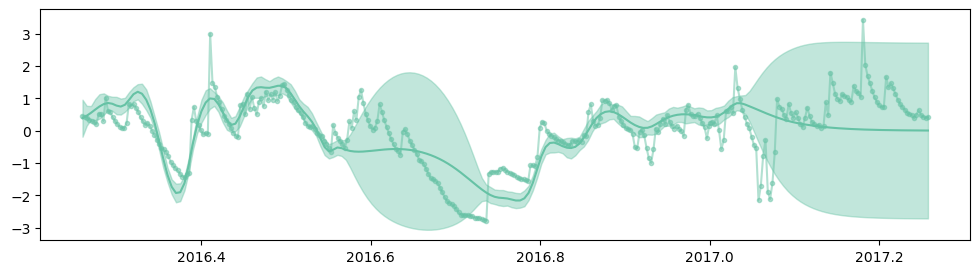

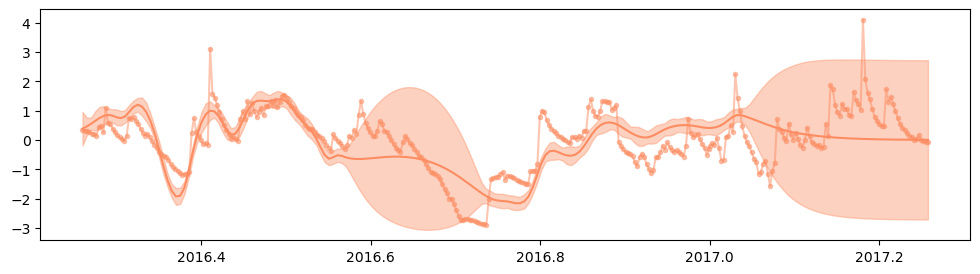

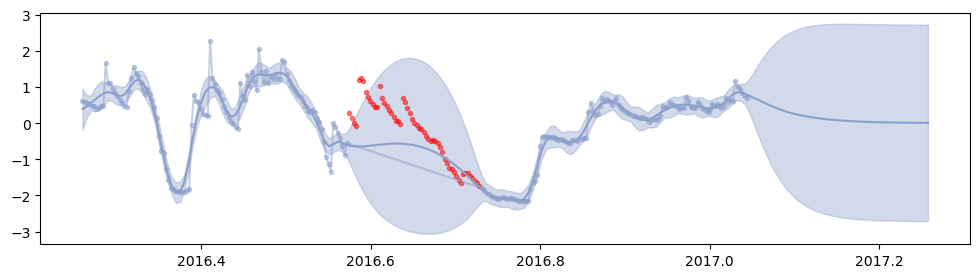

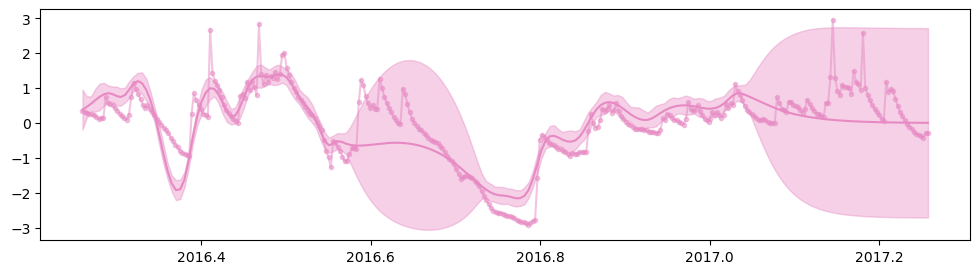

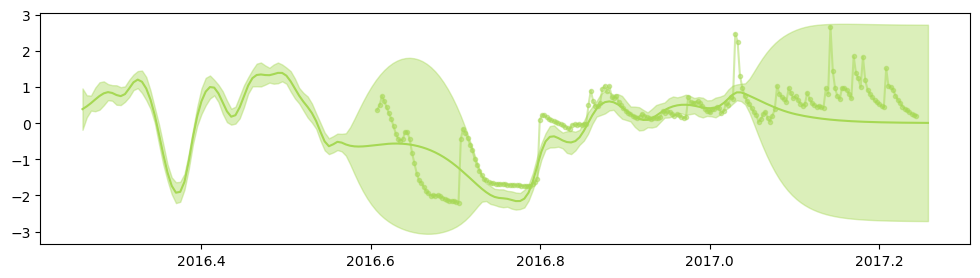

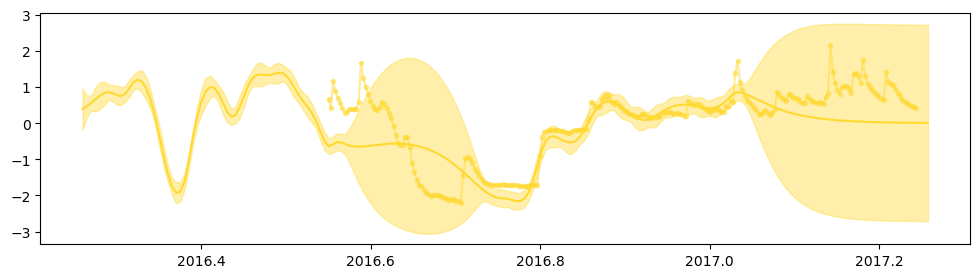

tf.Tensor(
[[-0.62114136]
 [-0.6340523 ]
 [-0.6423903 ]
 [-0.64692416]
 [-0.64826798]
 [-0.64703367]
 [-0.64369577]
 [-0.6387538 ]
 [-0.63258558]
 [-0.62557678]
 [-0.61804153]
 [-0.61027242]
 [-0.60252983]
 [-0.59505105]
 [-0.58803831]
 [-0.58169426]
 [-0.57618098]
 [-0.57166683]
 [-0.5682905 ]
 [-0.56618595]
 [-0.56543394]
 [-0.56610657]
 [-0.56825966]
 [-0.57195066]
 [-0.57723547]
 [-0.58415705]
 [-0.59276119]
 [-0.60309247]
 [-0.61519531]
 [-0.62912337]
 [-0.64492486]
 [-0.66264759]
 [-0.68233209]
 [-0.70401704]
 [-0.72773965]
 [-0.75354539]
 [-0.78149364]
 [-0.81164402]
 [-0.84405052]
 [-0.87875918]
 [-0.91581328]
 [-0.95524331]
 [-0.99707604]
 [-1.04128573]
 [-1.08778714]
 [-1.13647502]
 [-1.18722584]
 [-1.23989031]
 [-1.29429547]
 [-1.35023448]
 [-1.40746649]
 [-1.46570292]
 [-1.52461437]
 [-1.58380811]
 [-1.6428304 ]
 [-1.70115821]
 [-1.75818005]], shape=(57, 1), dtype=float64)


0.6838054114574694

In [11]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model4.predict_f(Xplot[:,0][:,None])
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model4.predict_f(Xtest)
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

╒════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                   │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ GPRFITC.kernel.kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ GPRFITC.kernel.kernels[0].lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ GPRFITC.kernel.kernels[1].W            │ Parameter │ 

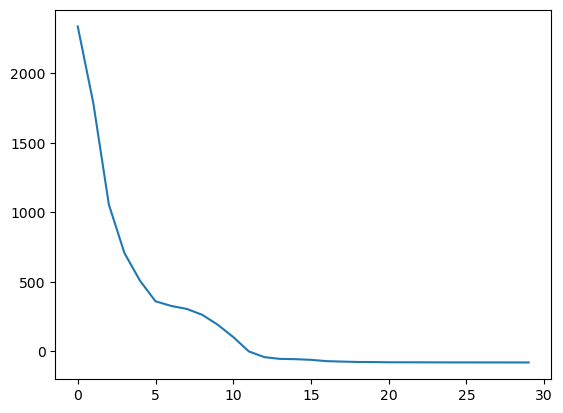

In [13]:
def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = len(substations) # Number of outputs
rank = 1 # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
kern = k * coreg
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))

l1 = gpf.likelihoods.Gaussian()

# now build the GP model as normal
model5 =  gpf.models.GPRFITC((X, y), kernel=kern, likelihood=l1, inducing_variable=LMCInducingPointsBase(ivs))


gpf.utilities.print_summary(model5)
# fit the covariance function parameters
optimize(model5)

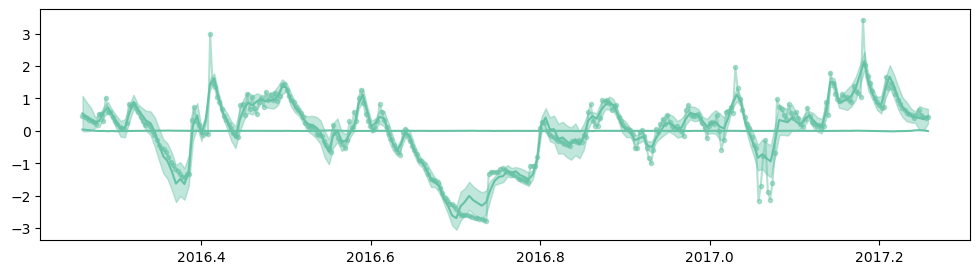

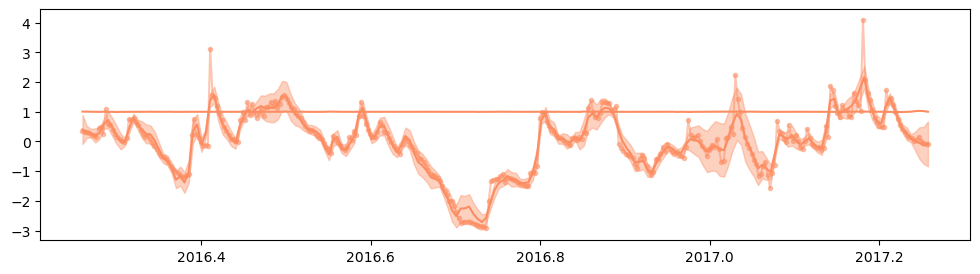

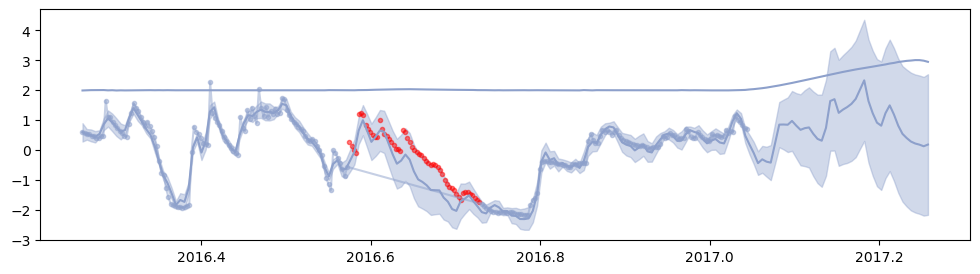

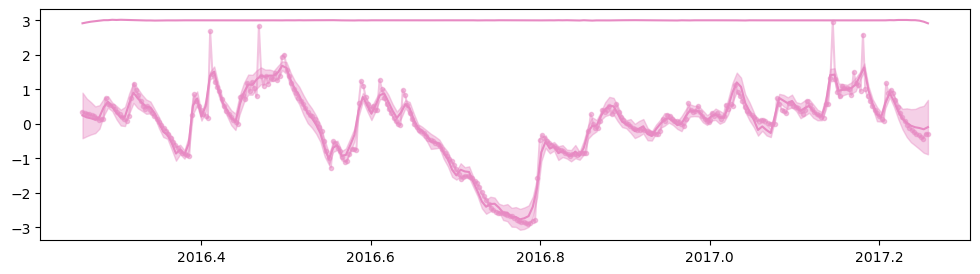

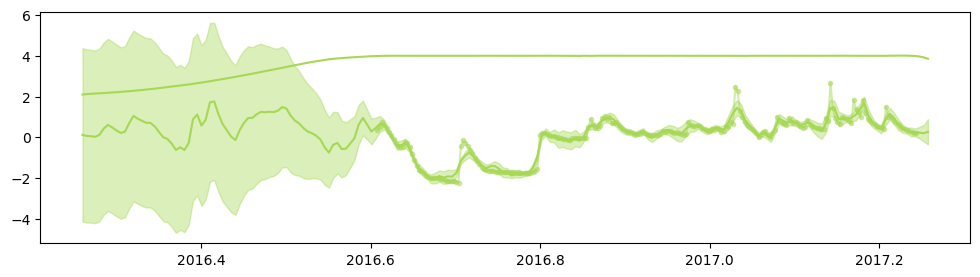

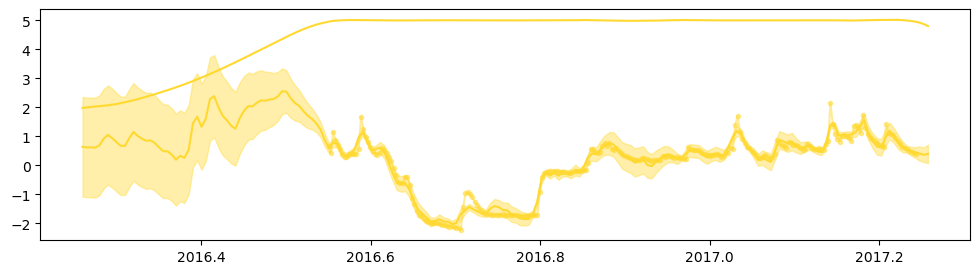

tf.Tensor(
[[-0.3964442   1.99999628]
 [-0.25332284  1.99934254]
 [-0.09793671  1.99987645]
 [ 0.23572445  2.00182672]
 [ 0.66163965  2.00547924]
 [ 0.94815482  2.00719622]
 [ 0.99320686  2.00577491]
 [ 0.82847898  2.00561531]
 [ 0.53806762  2.01009005]
 [ 0.30983996  2.0135862 ]
 [ 0.29945816  2.01606247]
 [ 0.41458219  2.01741221]
 [ 0.53843317  2.01859532]
 [ 0.64626206  2.02075304]
 [ 0.69113907  2.02234695]
 [ 0.60514982  2.02493185]
 [ 0.41261757  2.02728079]
 [ 0.19360817  2.02806695]
 [-0.00918105  2.02824221]
 [-0.21800989  2.02944006]
 [-0.40896422  2.03093812]
 [-0.45477724  2.03218275]
 [-0.37855093  2.03332128]
 [-0.26089783  2.03430701]
 [-0.15373792  2.03445979]
 [-0.15045747  2.03434397]
 [-0.32792636  2.03551339]
 [-0.55308071  2.03516602]
 [-0.74878895  2.03369344]
 [-0.90734103  2.0325046 ]
 [-1.00821163  2.03144566]
 [-1.04741825  2.03083851]
 [-1.08088331  2.02909888]
 [-1.14849321  2.02689544]
 [-1.23205118  2.02498048]
 [-1.32219028  2.0242765 ]
 [-1.39023635  2.

0.28383351589981726

In [14]:
from sklearn.metrics import mean_squared_error
from matplotlib import color_sequences
Xtst = Xtest.reshape(-1, 1)

colors = color_sequences["Set2"]
for index in range(output_dim):
    Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
    Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
    fmean, fvar = model5.predict_f(Xplot)
    plt.figure(figsize=(12, 3))
    if index == condition_index:  
       fmean_test, fvar_test = model5.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
       plt.plot(Xtest, ytest, "r.", alpha=0.5)
    plt.plot(Xplot[:,0], fmean, color=colors[index], label="source predictions")
    plt.plot(Ax[:,0], Ay[:,0], color=colors[index], marker=".", alpha=0.5, label="source")
    plt.fill_between(
        Xplot[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color=colors[index],
        alpha=0.4,
    )
plt.show()

print(fmean_test)
ours_mse = mean_squared_error(ytest, fmean_test[:,0])
ours_mse

CMOGP 0.13926685988572055
sCMOGP 0.17397412901279916
SVGP 0.4934023065675167
GPFITC 0.28383351589981726


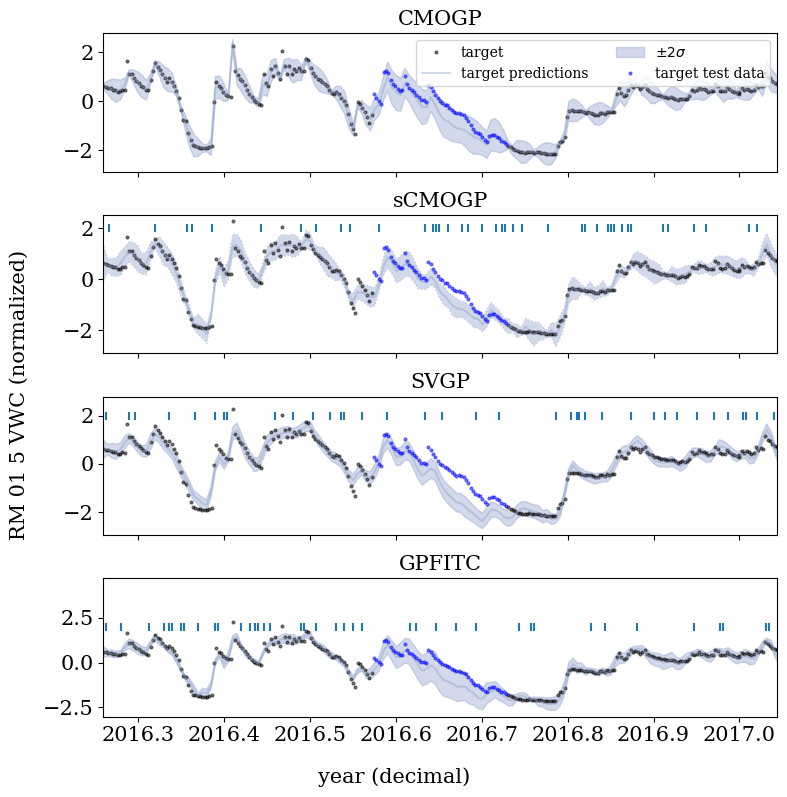

In [22]:
colors = color_sequences["Set2"]
plt.rcParams["font.family"] = "serif"
names = ["CMOGP", "sCMOGP", "SVGP", "GPFITC"]
fig, ((ax1, ax2, ax3, ax4)) = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
for i, (model, ax) in enumerate(zip([model1, model2, model3, model5], [ax1, ax2, ax3, ax4])):
    for index in [condition_index]:
        Ax, Ay = X[X[:,1] == index], y[y[:,1] == index]
        Xplot = np.hstack((np.linspace(min(X[:,0]), max(X[:,0]), 200)[:,None], index*np.ones((200, 1))))
        fmean, fvar = model.predict_f(Xplot)
        ymean, yvar = model.predict_y(Xplot)
        fmean_test, fvar_test = model.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
        ymean_test, yvar_test = model.predict_y(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))))
        ax.plot(Ax[:,0], Ay[:,0], color="k", marker=".", lw=0, ms=4, alpha=0.5, label=f"target")
        for j, (mean, var) in enumerate([(fmean, fvar)]):
            ax.plot(Xplot[:,0], mean[:,0], color=colors[index], alpha=0.4, label=f"target predictions")
            ax.fill_between(
                Xplot[:, 0],
                (mean[:,0] - 2 * np.sqrt(var)[:, 0]),
                (mean[:,0] + 2 * np.sqrt(var)[:, 0]),
                color=colors[index],
                alpha=0.4,
                label="$\pm 2\sigma$",
                linestyle=":" if i == 1 else "-"
            )
        ax.set_xlim(np.min(Ax[:,0]), np.max(Ax[:,0]))
        ax.set_title(names[i], fontsize=15)
        fig.supxlabel("year (decimal)", fontsize=15)
        fig.supylabel(f"RM {station_indices[condition_index]} {depths[condition_index]} VWC (normalized)", fontsize=15)
        ax.tick_params(axis="both", labelsize=15)
        ax.plot(Xtest, ytest, "b.", ms=4, alpha=0.5, label="target test data")
        if i > 0: 
            ivs = model.inducing_variable.Z.numpy()
            ivs_target = ivs[ivs[:,1] == condition_index]
            ax.scatter(ivs_target, 2*np.ones_like(ivs_target), marker="|", label="inducing variables") 
        if i == 0:
            ax.legend(ncols=2)
        #fig.suptitle("Interpolation of VWC at depth 5cm, station 1", fontsize=20)
        Xt, yt = X[X[:,1] == condition_index], y[y[:,1] == condition_index]
        ymean_nce, yvar_nce = model.predict_f(np.hstack((Xtest, index*np.ones((len(Xtest), 1)))) if names[i] != "SGPR" else model.predict_y(Xtest) )
        mse = mean_squared_error(ytest, fmean_test[:,0])
        print(names[i], mse)
plt.tight_layout()
plt.show()

In [ ]:
np.logspace(6, 14, 8, base=2)

array([   64.        ,   141.32345775,   312.06749548,   689.10089863,
        1521.65815208,  3360.09361821,  7419.68825765, 16384.        ])